In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

from google.colab import drive
from IPython.display import Audio
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import matplotlib.pyplot as plt


# 0. 주파수 이해

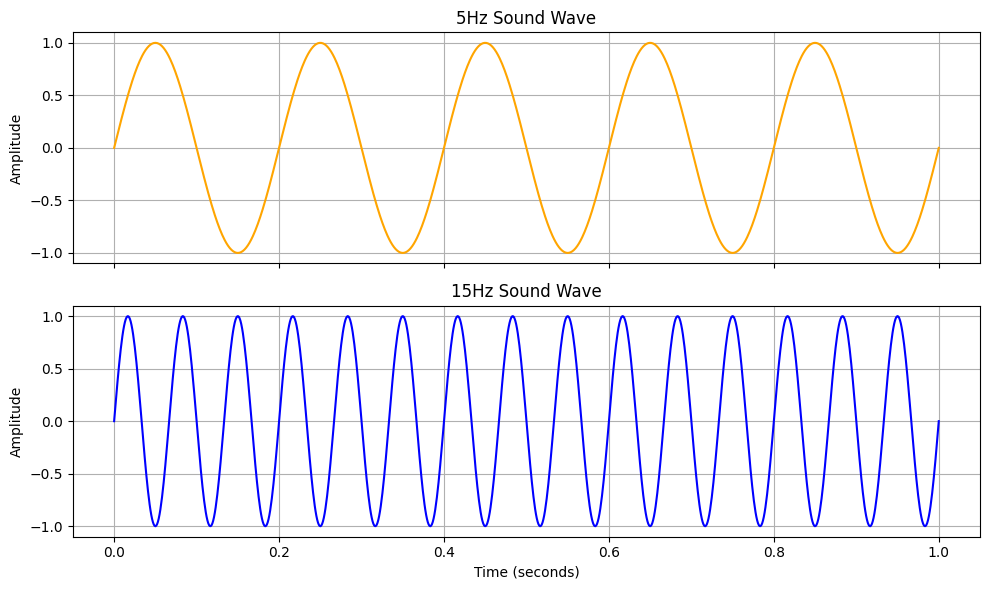

In [3]:
# 시간 (0초부터 1초까지 1000개의 샘플)
t = np.linspace(0, 1, 1000)

# 5Hz, 15Hz 사인파 생성
freq1 = 5  # 5Hz
freq2 = 15  # 15Hz
wave1 = np.sin(2 * np.pi * freq1 * t)
wave2 = np.sin(2 * np.pi * freq2 * t)

# 그래프
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# 5Hz 파형
axs[0].plot(t, wave1, color='orange')
axs[0].set_title("5Hz Sound Wave")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True)

# 15Hz 파형
axs[1].plot(t, wave2, color='blue')
axs[1].set_title("15Hz Sound Wave")
axs[1].set_xlabel("Time (seconds)")
axs[1].set_ylabel("Amplitude")
axs[1].grid(True)

# x축 눈금 조정 (0초에서 1초까지 눈금)
plt.xticks(np.arange(0, 1.1, 0.2))
plt.tight_layout()
plt.show()

# 1. 단일 주파수 파형

In [4]:
# 1) 단일 주파수
def generate_sine_wave(freq=400, sr=16000, duration=1.0, amplitude=0.3):
    """
    freq : 주파수 (Hz)
    sr   : 샘플레이트 (samples/sec)
    duration : 길이 (초)
    amplitude : 진폭 (소리 크기)
    """
    t = np.linspace(0, duration, int(sr*duration), endpoint=False)
    y = amplitude * np.sin(2 * np.pi * freq * t)
    return y, sr


y_single, sr = generate_sine_wave(freq=300, sr=16000, duration=1.0, amplitude=0.3)
print("Single frequency shape:", y_single.shape)
Audio(y_single, rate=sr)


Single frequency shape: (16000,)


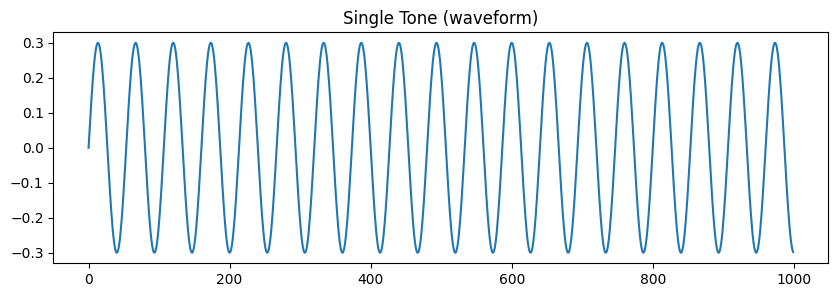

In [5]:
plt.figure(figsize=(10,3))
plt.plot(y_single[:1000])  # 첫 1000샘플
plt.title("Single Tone (waveform)")
plt.show()

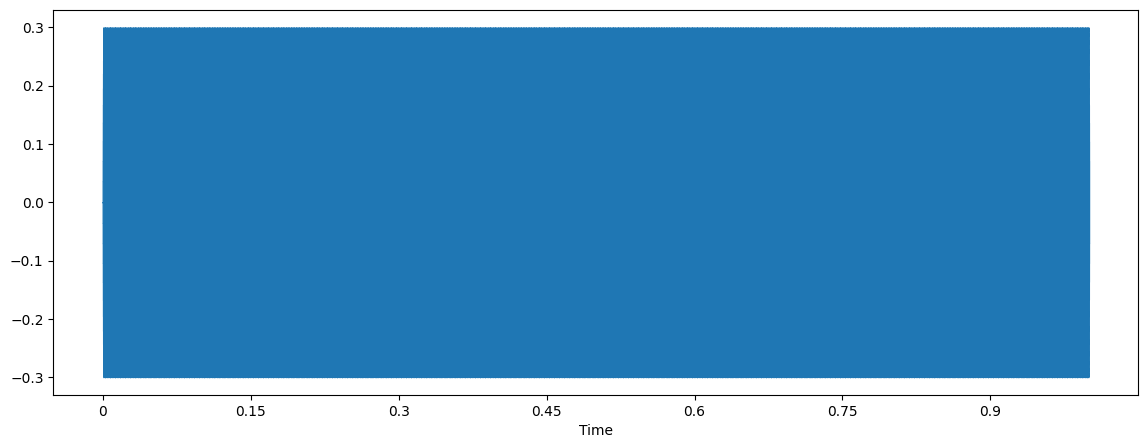

In [6]:
plt.figure( figsize = ( 14, 5 ) )
librosa.display.waveshow( y_single, sr=sr )
plt.show()

# 2. 다중 주파수 파형 재생

In [7]:
# 2) 여러 주파수 혼합
def generate_multi_tone(freqs=[200,300,400,500], sr=16000, duration=1.0, amplitude=0.3):
    t = np.linspace(0, duration, int(sr*duration), endpoint=False)
    y = np.zeros_like(t)
    for f in freqs:
        y += amplitude * np.sin(2*np.pi * f * t)

    return y, sr

y_mix, sr = generate_multi_tone(freqs=[200, 300, 400, 500, 600], sr=16000, duration=1.0, amplitude=0.3)
print("Multi frequency shape:", y_mix.shape)
Audio(y_mix, rate=sr)

Multi frequency shape: (16000,)


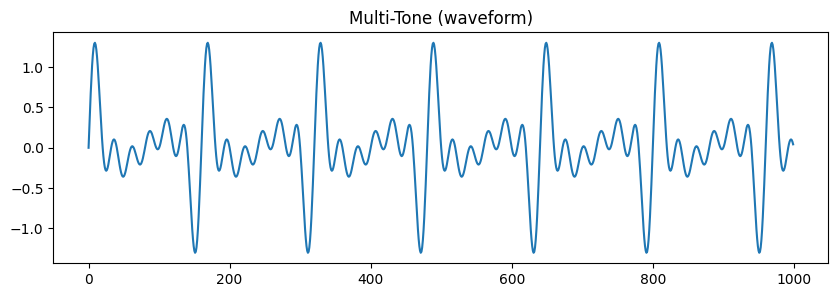

In [8]:
plt.figure(figsize=(10,3))
plt.plot(y_mix[:1000])      # 첫 1000샘플
plt.title("Multi-Tone (waveform)")
plt.show()

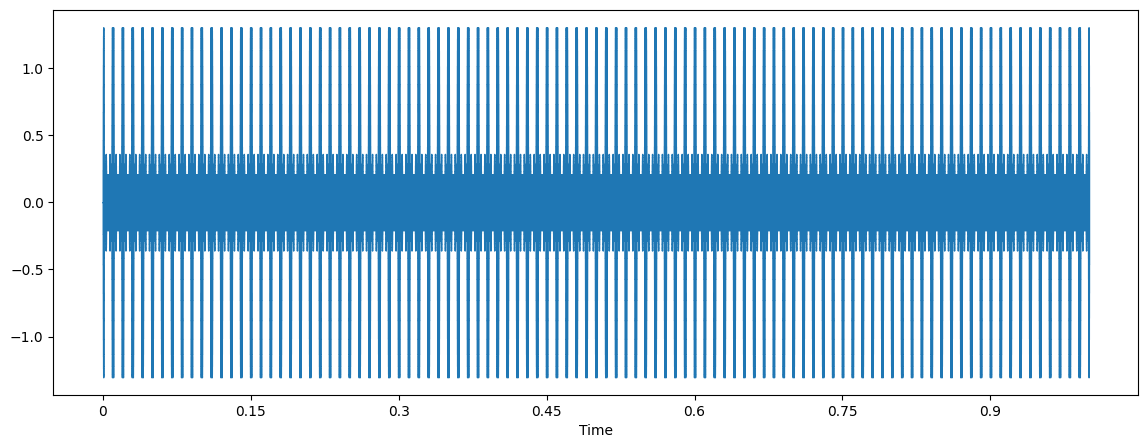

In [9]:
plt.figure( figsize = ( 14, 5 ) )
librosa.display.waveshow( y_mix, sr=sr )
plt.show()